## TransformerModel

Epoch 1/200, Train Loss: 123.67766295, Train Accuracy: 0.82700971
Epoch 1, Validation Loss: 24.37438887, Validation Accuracy: 0.85147128
Validation after Epoch 1: Loss=24.37438887, Accuracy=0.85147128
New best model saved at epoch 1 with validation loss: 24.37438887
Epoch 2/200, Train Loss: 92.73464273, Train Accuracy: 0.87586345
Epoch 2, Validation Loss: 17.17154283, Validation Accuracy: 0.88977113
Validation after Epoch 2: Loss=17.17154283, Accuracy=0.88977113
New best model saved at epoch 2 with validation loss: 17.17154283
Epoch 3/200, Train Loss: 81.95390619, Train Accuracy: 0.88947843
Epoch 3, Validation Loss: 16.28004917, Validation Accuracy: 0.89771135
Validation after Epoch 3: Loss=16.28004917, Accuracy=0.89771135
New best model saved at epoch 3 with validation loss: 16.28004917
Epoch 4/200, Train Loss: 74.57640015, Train Accuracy: 0.90279307
Epoch 4, Validation Loss: 15.96861857, Validation Accuracy: 0.90284914
Validation after Epoch 4: Loss=15.96861857, Accuracy=0.90284914
N

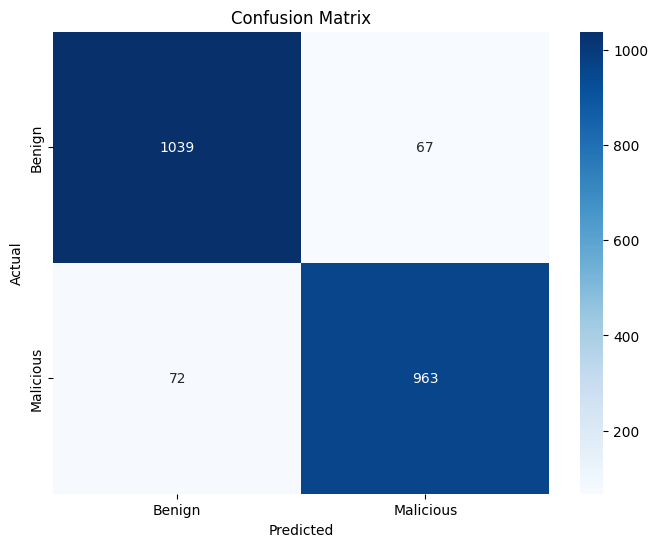

Precision: 0.93495146
Recall: 0.93043478
F1 Score: 0.93268765
ROC AUC: 0.93492806


In [1]:
import pandas as pd
import numpy as np
import time
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score, roc_auc_score, roc_curve, cohen_kappa_score
from torch.utils.tensorboard import SummaryWriter
import matplotlib.pyplot as plt
import seaborn as sns

# Transformer Model
class TransformerModel(nn.Module):
    def __init__(self, input_dim, output_dim, num_layers, heads, hidden_dim, dropout):
        super(TransformerModel, self).__init__()
        
        # Adjust input_dim to be divisible by heads
        if input_dim % heads != 0:
            input_dim = (input_dim // heads) * heads
        
        self.input_dim = input_dim
        self.encoder_layer = nn.TransformerEncoderLayer(
            d_model=input_dim,
            nhead=heads,
            dim_feedforward=hidden_dim,
            dropout=dropout,
            batch_first=True
        )
        self.transformer_encoder = nn.TransformerEncoder(self.encoder_layer, num_layers=num_layers)
        self.fc = nn.Linear(input_dim, output_dim)

    def forward(self, src):
        if src.shape[2] < self.input_dim:
            padded_src = torch.zeros(
                src.shape[0], src.shape[1], self.input_dim, device=src.device
            )
            padded_src[:, :, :src.shape[2]] = src
            src = padded_src
        elif src.shape[2] > self.input_dim:
            src = src[:, :, :self.input_dim]

        output = self.transformer_encoder(src)
        output = self.fc(output[:, -1, :])
        return output

# Dataset class
class CSVDataset(Dataset):
    def __init__(self, X, y):
        self.X = X
        self.y = y

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        x_value = torch.tensor(self.X[idx], dtype=torch.float)
        y_value = torch.tensor(self.y[idx], dtype=torch.long)
        return x_value, y_value

# Load data
def load_data(csv_file):
    dataset = pd.read_csv(csv_file)
    X = dataset.drop(['Package_Name', 'Level'], axis=1)
    y = dataset['Level']
    
    label_encoder = LabelEncoder()
    y = label_encoder.fit_transform(y)
    
    imputer = SimpleImputer(strategy='mean')
    X_imputed = imputer.fit_transform(X.select_dtypes(include='number'))
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X_imputed)
    
    X_train, X_temp, y_train, y_temp = train_test_split(X_scaled, y, test_size=0.3, random_state=42)
    X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)
    
    
    input_dim = ((X_train.shape[1] // 8) * 8)
    X_train = np.pad(X_train, ((0, 0), (0, max(0, input_dim - X_train.shape[1]))), mode='constant')[:, :input_dim]
    X_val = np.pad(X_val, ((0, 0), (0, max(0, input_dim - X_val.shape[1]))), mode='constant')[:, :input_dim]
    X_test = np.pad(X_test, ((0, 0), (0, max(0, input_dim - X_test.shape[1]))), mode='constant')[:, :input_dim]

    train_dataset = CSVDataset(X_train, y_train)
    val_dataset = CSVDataset(X_val, y_val)
    test_dataset = CSVDataset(X_test, y_test)
    
    return train_dataset, val_dataset, test_dataset, input_dim

# Training
def train_model(train_loader, val_loader, model, criterion, optimizer, writer, epochs, save_path="best_model.pth"):
    model.train()
    total_loss = 0
    total_correct = 0
    total_samples = 0
    best_val_loss = float('inf')  # Initialize with infinity
    start_time = time.time()

    for epoch in range(epochs):
        # Training phase
        epoch_loss = 0
        epoch_correct = 0
        epoch_samples = 0
        for x_values, y_values in train_loader:
            x_values = x_values.unsqueeze(1)  # Add sequence dimension
            optimizer.zero_grad()
            output = model(x_values)
            loss = criterion(output, y_values)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()
            _, predicted = torch.max(output, 1)
            epoch_correct += (predicted == y_values).sum().item()
            epoch_samples += y_values.size(0)

        epoch_accuracy = epoch_correct / epoch_samples
        total_loss += epoch_loss
        total_correct += epoch_correct
        total_samples += epoch_samples

        # Log training metrics
        writer.add_scalar("Train/Loss", epoch_loss, epoch + 1)
        writer.add_scalar("Train/Accuracy", epoch_accuracy, epoch + 1)

        print(f"Epoch {epoch + 1}/{epochs}, Train Loss: {epoch_loss:.8f}, Train Accuracy: {epoch_accuracy:.8f}")

        # Validation phase
        val_loss, val_time, val_accuracy = validate_model(val_loader, model, criterion, writer, epoch)

        # Log validation metrics
        writer.add_scalar("Validation/Loss", val_loss, epoch + 1)
        writer.add_scalar("Validation/Accuracy", val_accuracy, epoch + 1)

        print(f"Validation after Epoch {epoch + 1}: Loss={val_loss:.8f}, Accuracy={val_accuracy:.8f}")

        # Save the best model
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            torch.save(model.state_dict(), save_path)
            print(f"New best model saved at epoch {epoch + 1} with validation loss: {val_loss:.8f}")

    train_time = time.time() - start_time
    train_accuracy = total_correct / total_samples
    return total_loss, train_time, train_accuracy

# Validation
def validate_model(val_loader, model, criterion, writer, epoch):
    model.eval()
    val_loss = 0
    val_correct = 0
    val_samples = 0
    start_time = time.time()
    with torch.no_grad():
        for x_values, y_values in val_loader:
            x_values = x_values.unsqueeze(1)  # Add sequence dimension
            output = model(x_values)
            loss = criterion(output, y_values)
            val_loss += loss.item()
            _, predicted = torch.max(output, 1)
            val_correct += (predicted == y_values).sum().item()
            val_samples += y_values.size(0)
    val_accuracy = val_correct / val_samples
    val_time = time.time() - start_time
    writer.add_scalar("Validation/Loss", val_loss, epoch + 1)
    writer.add_scalar("Validation/Accuracy", val_accuracy, epoch + 1)

    print(f"Epoch {epoch + 1}, Validation Loss: {val_loss:.8f}, Validation Accuracy: {val_accuracy:.8f}")
    
    return val_loss, val_time, val_accuracy

# Testing
def test_model(test_loader, model, writer):
    model.eval()
    correct = 0
    total = 0
    y_true = []
    y_pred = []
    start_time = time.time()
    with torch.no_grad():
        for x_values, y_values in test_loader:
            x_values = x_values.unsqueeze(1)
            outputs = model(x_values)
            _, predicted = torch.max(outputs, 1)
            total += y_values.size(0)
            correct += (predicted == y_values).sum().item()
            y_true.extend(y_values.tolist())
            y_pred.extend(predicted.tolist())
    test_time = time.time() - start_time
    accuracy = correct / total
    conf_matrix = confusion_matrix(y_true, y_pred)
    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    roc_auc = roc_auc_score(y_true, y_pred)
    kappa = cohen_kappa_score(y_true, y_pred)
    writer.add_scalar("Test/Accuracy", accuracy, 1)
    return accuracy, conf_matrix, precision, recall, f1, roc_auc, kappa, test_time

# Visualization
def plot_metrics(conf_matrix, precision, recall, f1, roc_auc):
    plt.figure(figsize=(8, 6))
    sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['Benign', 'Malicious'], yticklabels=['Benign', 'Malicious'])
    plt.title('Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.savefig('Transformer Confusion Matrix.png')  # Save the plot
    plt.show()

    print(f"Precision: {precision:.8f}")
    print(f"Recall: {recall:.8f}")
    print(f"F1 Score: {f1:.8f}")
    print(f"ROC AUC: {roc_auc:.8f}")

# Hyperparameters
output_dim = 2
num_layers = 6
heads = 8
hidden_dim = 256
dropout = 0.1
batch_size = 32
epochs = 200
learning_rate = 0.001

# Load data and initialize model
csv_file = 'D:/Final Version/Step 14 CombinedTraces/CombinedDataset/FinalCombinedBenignMaliciousDataset-v3.csv'
train_dataset, val_dataset, test_dataset, input_dim = load_data(csv_file)
model = TransformerModel(input_dim, output_dim, num_layers, heads, hidden_dim, dropout)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

# TensorBoard Writer
writer = SummaryWriter("logs/transformer")

# Train, validate, and test
train_loss, train_time, train_accuracy = train_model(train_loader, val_loader, model, criterion, optimizer, writer, epochs, save_path="best_model.pth")
val_loss, val_time, val_accuracy = validate_model(val_loader, model, criterion, writer, epochs)
test_accuracy, conf_matrix, precision, recall, f1, roc_auc, kappa, test_time = test_model(test_loader, model, writer)

print(f"\nTrain Time: {train_time:.8f} seconds")
print(f"Train Accuracy: {train_accuracy:.8f}")
print(f"Train Loss: {train_loss:.8f}")

print(f"\nValidation Time: {val_time:.8f} seconds")
print(f"Validation Accuracy: {val_accuracy:.8f}")
print(f"Validation Loss: {val_loss:.8f}")

print(f"\nTest Time: {test_time:.8f} seconds")
print(f"Accuracy: {test_accuracy:.8f}")

print(f"Precision: {precision:.8f}")
print(f"Recall: {recall:.8f}")
print(f"F1 Score: {f1:.8f}")
print(f"ROC AUC: {roc_auc:.8f}")
print(f"Kappa: {kappa:.8f}")

# Plot metrics
# Plot metrics
plot_metrics(conf_matrix, precision, recall, f1, roc_auc)